<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Ross%2C%20Stephen%20A.%20(1976)%20The%20arbitrage%20theory%20of%20capital%20asset%20pricing/arbitrage_theory_of_capital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Title: APT Theory Illustration in Python

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -----------------------------
# Step 1: Define the factors and asset sensitivities
# -----------------------------

np.random.seed(42)

n_assets = 10  # number of assets
n_factors = 3  # number of systematic factors
n_periods = 250  # number of time periods (days, months, etc.)

# Simulate factor returns (assume normally distributed)
factor_returns = np.random.normal(0, 0.01, size=(n_periods, n_factors))
factor_names = [f"F{i+1}" for i in range(n_factors)]
factor_df = pd.DataFrame(factor_returns, columns=factor_names)

# Random sensitivities (betas) of assets to each factor
betas = np.random.normal(1, 0.2, size=(n_assets, n_factors))

# Simulate idiosyncratic noise for each asset
idiosyncratic_noise = np.random.normal(0, 0.02, size=(n_periods, n_assets))


This Python code simulates a simple illustration of **Arbitrage Pricing Theory (APT)**. It creates random returns for three systematic factors over 250 periods and assigns each of ten assets random sensitivities (betas) to these factors. Each asset also has its own unique idiosyncratic noise. Together, this setup models how asset returns are influenced both by common market factors and by asset-specific randomness, forming the foundation for simulating APT-driven returns.


In [7]:
# -----------------------------
# Step 2: Generate asset returns based on APT model
# -----------------------------

# r_i = sum_j(beta_ij * F_j) + epsilon_i
asset_returns = factor_returns @ betas.T + idiosyncratic_noise
asset_names = [f"Asset_{i+1}" for i in range(n_assets)]
asset_df = pd.DataFrame(asset_returns, columns=asset_names)


This part of the code calculates the **asset returns** using the APT model. Each asset’s return is computed as the sum of its sensitivities (betas) multiplied by the factor returns, plus its idiosyncratic noise. The results are stored in a table with one column per asset, showing how both systematic factors and asset-specific randomness drive the simulated returns.


In [8]:
# -----------------------------
# Step 3: Calculate expected returns and factor risk premiums
# -----------------------------

expected_returns = asset_df.mean()
factor_risk_premiums = factor_df.mean()  # simplified approach

# Show results
print("Expected Returns (simulated):")
print(expected_returns)
print("\nFactor Risk Premiums (mean factor returns):")
print(factor_risk_premiums)

Expected Returns (simulated):
Asset_1     0.000306
Asset_2     0.001421
Asset_3    -0.000647
Asset_4    -0.000504
Asset_5     0.000426
Asset_6     0.000885
Asset_7    -0.002426
Asset_8    -0.000896
Asset_9     0.001350
Asset_10    0.003216
dtype: float64

Factor Risk Premiums (mean factor returns):
F1    0.000594
F2   -0.001405
F3    0.000275
dtype: float64


This section calculates the **average (expected) returns** for each asset and the **factor risk premiums** using the simulated data. The expected return of an asset is simply the mean of its simulated returns over all periods, while the factor risk premium is the mean return of each systematic factor. These values summarize how much, on average, each asset and factor contributes to returns.


In [9]:
# -----------------------------
# Step 4: Test the linear relationship of APT
# -----------------------------
# Regress expected returns on factor sensitivities
import statsmodels.api as sm

X = sm.add_constant(betas)  # add intercept
y = expected_returns.values
model = sm.OLS(y, X).fit()

print("\nAPT Linear Relationship Regression Results:")
print(model.summary())


APT Linear Relationship Regression Results:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     1.782
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.250
Time:                        00:16:23   Log-Likelihood:                 54.216
No. Observations:                  10   AIC:                            -100.4
Df Residuals:                       6   BIC:                            -99.22
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

This part of the code tests the main idea behind the Arbitrage Pricing Theory (APT)that an asset’s expected return can be explained as a linear combination of its sensitivities (betas) to underlying factors and the factors’ risk premiums. It does this by running a linear regression where the expected returns of the assets are the dependent variable and the betas are the independent variables. The regression results show how well the expected returns align with the APT model and provide estimates of the factor risk premiums, effectively checking whether the APT relationship holds in the simulated data.


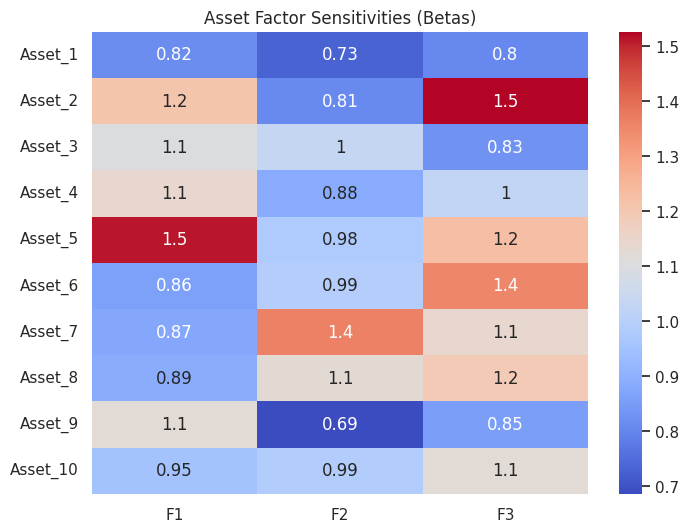

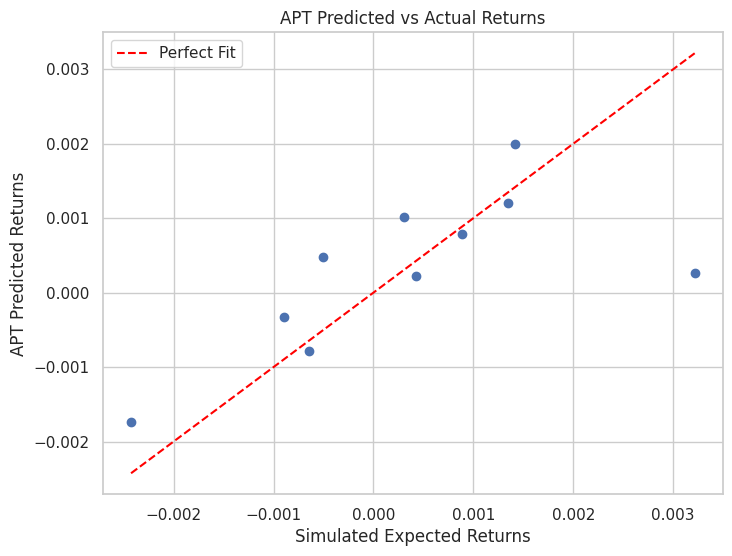

In [10]:
# -----------------------------
# Step 5: Visualizations
# -----------------------------

# Heatmap of factor sensitivities
plt.figure(figsize=(8,6))
sns.heatmap(betas, annot=True, cmap="coolwarm", xticklabels=factor_names, yticklabels=asset_names)
plt.title("Asset Factor Sensitivities (Betas)")
plt.show()

# Expected returns vs APT predicted returns
apt_predicted = model.predict(X)
plt.figure(figsize=(8,6))
plt.scatter(expected_returns, apt_predicted)
plt.plot([expected_returns.min(), expected_returns.max()],
         [expected_returns.min(), expected_returns.max()],
         color='red', linestyle='--', label="Perfect Fit")
plt.xlabel("Simulated Expected Returns")
plt.ylabel("APT Predicted Returns")
plt.title("APT Predicted vs Actual Returns")
plt.legend()
plt.show()

This scatter plot compares the returns of each asset (x-axis) with the returns predicted by the APT model (y-axis). Each point represents an asset, and the red line represents a perfect fit. While the APT model predicts returns based on factor sensitivities and risk premiums, the points do not all lie exactly on the line, with some deviating by varying amounts, showing that in practice the model does not capture every variation perfectly. These deviations illustrate the effect of noise or other real-world imperfections, highlighting that the ideal linear relationship assumed by APT may not hold exactly in actual or noisy simulated data.